# Security and Scalability Analysis


# 🛡️ Security Analysis: The "Trusted Insider" Attack

This simulation explores a critical vulnerability in link-state protocols: the **Compromised Trusted Node**. Even with HMAC signatures ensuring message authenticity, the network remains vulnerable if a trusted router begins broadcasting "poisoned" data.

### 1. Attack Mechanism: Traffic Hijacking
The `MaliciousAHRPRouter` class simulates an administrative breach where node **R4** is compromised.
* **Metric Poisoning:** The attacker claims ultra-low latency (0.1ms) and massive bandwidth (1000Gbps) to every other node in the network.
* **The "Sinkhole":** Because AHRP always seeks the most efficient path, other routers see these fake metrics and recalculate their routes to pass through **R4**, effectively hijacking the traffic flow.

### 2. The Role of HMAC in this Scenario
* **Verification:** The poisoned Link State Updates (LSUs) are accepted because they are signed with the correct administrative key.
* **The Lesson:** Cryptographic signatures prove **who** sent the message, but they do not prove that the **content** of the message is truthful. This highlights the need for secondary anomaly detection or behavioral analysis in secure routing.

---

### 🔍 Attack Impact Summary
| Status | Integrity | Confidentiality | Network Path |
| :--- | :--- | :--- | :--- |
| **Normal** | ✅ Verified | ✅ Secure | Optimized via metrics |
| **Under Attack** | ❌ Poisoned | ⚠️ At Risk | Diverted through R4 |

[10:39:40] [SYSTEM] Initializing Secure Network Convergence...


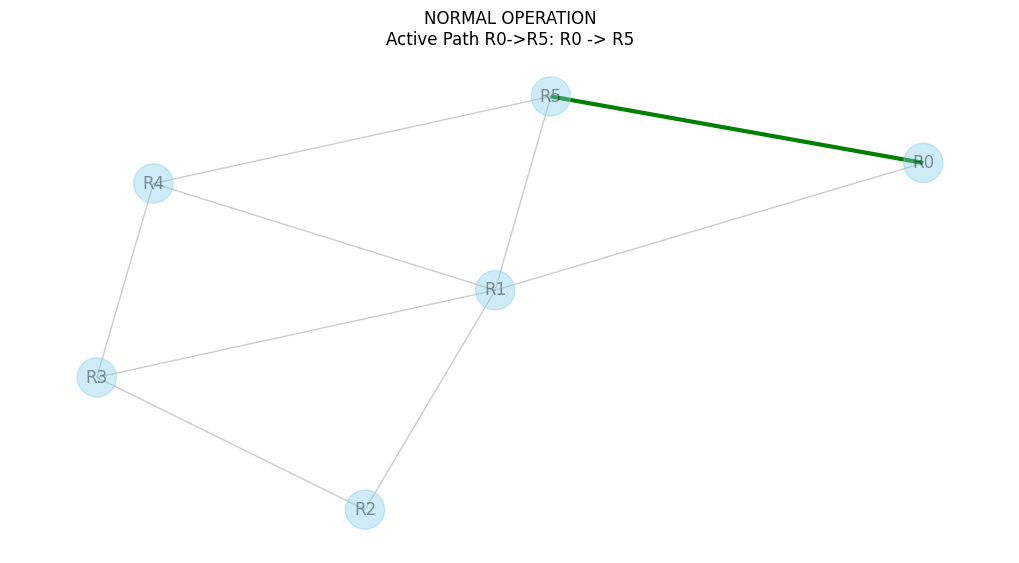


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[10:39:40] [SYSTEM] SECURITY BREACH: R4 Administrative Key Compromised!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

[10:39:40] [R4] ATTACK: Broadcasting poisoned LSU with fake metrics.
[10:39:40] [R4] ATTACK: Broadcasting poisoned LSU with fake metrics.


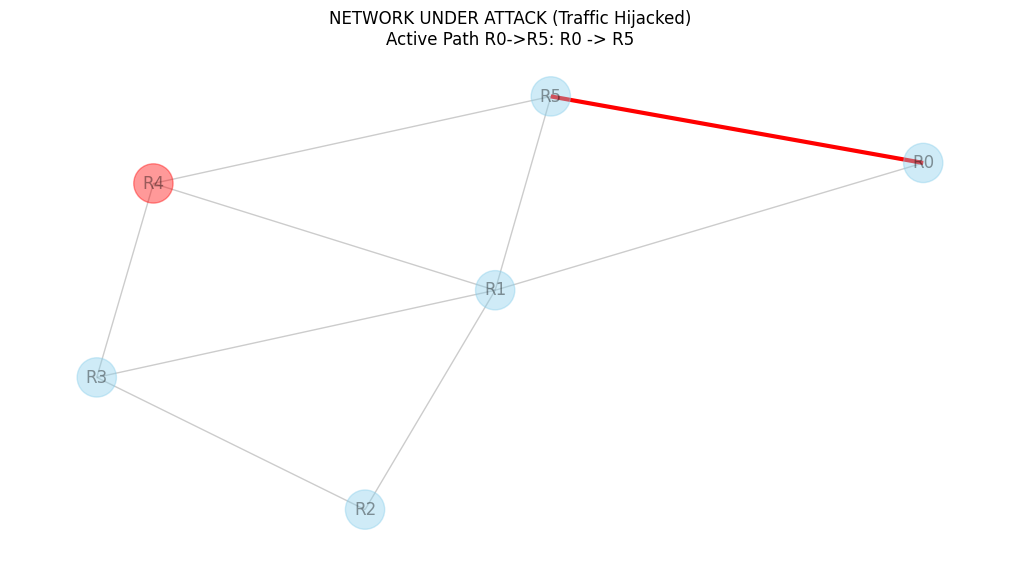


=== ATTACK SUMMARY ===


In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import time
import copy
import hmac
import hashlib

# -----------------------------
# CONFIG & SECURITY
# -----------------------------
SECRET_KEYS = {
    "R0": b"secret0", "R1": b"secret1", "R2": b"secret2",
    "R3": b"secret3", "R4": b"secret4", "R5": b"secret5"
}

METRIC_WEIGHTS = {"w1_latency": 0.6, "w2_bandwidth": 0.4}

def sign_message(message, source_id):
    key = SECRET_KEYS.get(source_id, b"default")
    return hmac.new(key, str(message).encode(), hashlib.sha256).hexdigest()

def verify_signature(message, signature, source_id):
    expected = sign_message(message, source_id)
    return hmac.compare_digest(expected, signature)

def log_event(router_id, message, level="INFO"):
    colors = {"INFO": "\033[94m", "SUCCESS": "\033[92m", "WARNING": "\033[93m", "CRITICAL": "\033[91m", "RESET": "\033[0m"}
    print(f"{colors.get(level, '')}[{time.strftime('%H:%M:%S')}] [{router_id}] {message}{colors['RESET']}")

# -----------------------------
# NETWORK INITIALIZATION
# -----------------------------
G = nx.Graph()
nodes = ["R0", "R1", "R2", "R3", "R4", "R5"]
G.add_nodes_from(nodes)
edges = [
    ("R0", "R1", 10, 100), ("R1", "R2", 15, 80), ("R2", "R3", 20, 70),
    ("R3", "R4", 10, 90), ("R4", "R5", 15, 60), ("R0", "R5", 50, 50),
    ("R1", "R4", 25, 75), ("R1", "R5", 40, 50), ("R1", "R3", 25, 100)
]
for u, v, latency, bandwidth in edges:
    G.add_edge(u, v, base_latency=latency, bandwidth=bandwidth)

# -----------------------------
# ROUTER CLASSES
# -----------------------------
class AHRPRouter:
    def __init__(self, router_id, neighbors_info):
        self.id = router_id
        self.local_interfaces = neighbors_info
        self.lsdb = {}
        self.topology = nx.Graph()
        self.routing_table = {}
        self.seq_num = 0

    def generate_lsu(self):
        self.seq_num += 1
        data = {"origin": self.id, "seq": self.seq_num, "links": self.local_interfaces}
        return {"data": data, "signature": sign_message(data, self.id)}

    def receive_lsu(self, packet):
        data, signature = packet['data'], packet['signature']
        origin, incoming_seq = data['origin'], data['seq']
        if not verify_signature(data, signature, origin): return False
        if origin not in self.lsdb or incoming_seq > self.lsdb[origin]:
            self.lsdb[origin] = incoming_seq
            self._update_topology(origin, data['links'])
            return True
        return False

    def _update_topology(self, origin, links):
        for neighbor, attr in links.items():
            latency, bandwidth = attr.get('base_latency', 50), attr.get('bandwidth', 10)
            cost = (METRIC_WEIGHTS['w1_latency'] * (latency / 50)) + (METRIC_WEIGHTS['w2_bandwidth'] * (100 / (bandwidth + 1)))
            self.topology.add_edge(origin, neighbor, weight=round(cost, 4))

    def recalculate_routes(self):
        for target in [n for n in self.topology.nodes if n != self.id]:
            try:
                self.routing_table[target] = {
                    "path": nx.dijkstra_path(self.topology, self.id, target, weight='weight'),
                    "cost": nx.dijkstra_path_length(self.topology, self.id, target, weight='weight')
                }
            except: self.routing_table[target] = {"path": [], "cost": float('inf')}

class MaliciousAHRPRouter(AHRPRouter):
    def generate_lsu(self):
        self.seq_num += 1
        # Attack Logic: Claim ultra-low cost to all nodes to hijack traffic
        fake_links = {node: {'base_latency': 0.1, 'bandwidth': 1000} for node in nodes if node != self.id}
        data = {"origin": self.id, "seq": self.seq_num, "links": fake_links}
        log_event(self.id, "ATTACK: Broadcasting poisoned LSU with fake metrics.", "WARNING")
        return {"data": data, "signature": sign_message(data, self.id)}

# -----------------------------
# SIMULATION & VISUALIZATION
# -----------------------------
def visualize_status(graph, routers, source, dest, title, attack_active=False):
    pos = nx.spring_layout(graph, seed=42)
    plt.figure(figsize=(10, 5))
    path = routers[source].routing_table.get(dest, {}).get('path', [])
    path_edges = list(zip(path, path[1:]))
    
    node_colors = ['red' if n == "R4" and attack_active else 'skyblue' for n in graph.nodes()]
    nx.draw(graph, pos, with_labels=True, node_color=node_colors, node_size=800, edge_color='gray', alpha=0.4)
    if path_edges:
        nx.draw_networkx_edges(graph, pos, edgelist=path_edges, edge_color='red' if attack_active else 'green', width=3)
    
    plt.title(f"{title}\nActive Path {source}->{dest}: {' -> '.join(path)}")
    plt.show()

def main():
    # PHASE 1: Normal Operation
    log_event("SYSTEM", "Initializing Secure Network Convergence...", "INFO")
    ahrp_routers = {n: AHRPRouter(n, {nbr: G.get_edge_data(n, nbr) for nbr in G.neighbors(n)}) for n in G.nodes()}
    
    for _ in range(2):
        for r_src in ahrp_routers.values():
            lsu = r_src.generate_lsu()
            for r_dst in ahrp_routers.values():
                if r_src.id != r_dst.id: r_dst.receive_lsu(lsu)
    
    for r in ahrp_routers.values(): r.recalculate_routes()
    visualize_status(G, ahrp_routers, "R0", "R5", "NORMAL OPERATION")

    # PHASE 2: The Attack
    print("\n" + "!"*60)
    log_event("SYSTEM", "SECURITY BREACH: R4 Administrative Key Compromised!", "CRITICAL")
    print("!"*60 + "\n")
    
    ahrp_routers["R4"] = MaliciousAHRPRouter("R4", {nbr: G.get_edge_data("R4", nbr) for nbr in G.neighbors("R4")})

    for _ in range(2):
        for r_src in ahrp_routers.values():
            lsu = r_src.generate_lsu()
            for r_dst in ahrp_routers.values():
                if r_src.id != r_dst.id: 
                    if r_dst.receive_lsu(lsu) and r_src.id == "R4":
                        log_event(r_dst.id, f"VULNERABILITY: Poisoned LSU from R4 accepted (Valid HMAC).", "WARNING")

    for r in ahrp_routers.values(): r.recalculate_routes()
    visualize_status(G, ahrp_routers, "R0", "R5", "NETWORK UNDER ATTACK (Traffic Hijacked)", attack_active=True)

    print("\n=== ATTACK SUMMARY ===")
    path = ahrp_routers["R0"].routing_table["R5"]["path"]
    if "R4" in path:
        log_event("ANALYSIS", f"CRITICAL: Traffic from R0 to R5 diverted through Attacker (R4).", "CRITICAL")
        log_event("ANALYSIS", "Integrity: COMPROMISED | Confidentiality: AT RISK", "WARNING")

if __name__ == "__main__":
    main()

## 🏁 Large-Scale Mesh & Node Failure Resilience

This section pushes the simulation to a **10-node ($R0$–$R9$) complex mesh**. It demonstrates how the **Secure Link-State** protocol performs under high-stress conditions, specifically the total failure of a central routing node.

### 🛡️ Resilience Logic
* **Dynamic Flooding:** When **R6** fails, its neighbors ($R1$, $R5$) broadcast signed updates with an incremented **Sequence Number**.
* **Path Recovery:** Using **Dijkstra’s Algorithm**, the remaining routers find the new "best" path. The visualization highlights the shift from the original green path to the orange recovery path.
* **Loop Prevention:** The `lsdb` (Link-State Database) uses sequence tracking to ensure routers don't process redundant or outdated information.

### 📊 Visualization Summary
* **Normal Operation:** Shows the optimal path from $R0$ to $R5$ through a healthy network.
* **Post-Failure:** Displays the network after $R6$ is removed, showing how traffic "bends" around the failure to maintain connectivity.

[*] Initializing 10-node mesh convergence...
[SUCCESS] Normal Path R0 to R5: ['R0', 'R1', 'R6', 'R5']

[!] CRITICAL FAILURE: R6 and its links are down.
[SUCCESS] Re-converged Path R0 to R5: ['R0', 'R9', 'R4', 'R5']


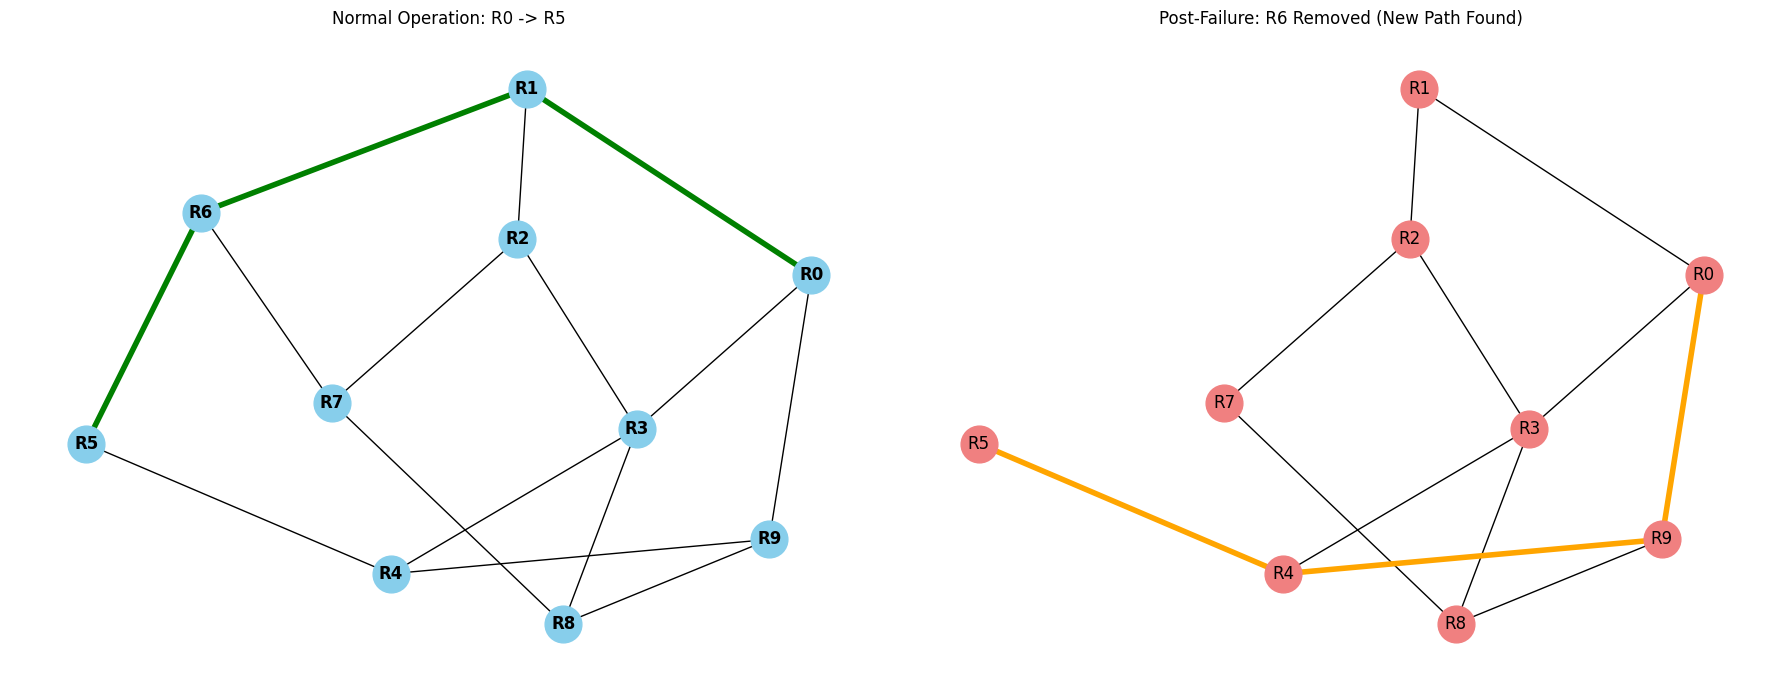

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import hmac
import hashlib

# -----------------------------
# CONFIG & SECURITY
# -----------------------------
# Expanded keys for 10 routers
SECRET_KEYS = {f"R{i}": f"secret{i}".encode() for i in range(10)}

def sign_message(message, source_id):
    key = SECRET_KEYS.get(source_id, b"default")
    return hmac.new(key, str(message).encode(), hashlib.sha256).hexdigest()

def verify_signature(message, signature, source_id):
    return hmac.compare_digest(sign_message(message, source_id), signature)

# -----------------------------
# EXPANDED NETWORK SETUP
# -----------------------------
G = nx.Graph()
nodes = [f"R{i}" for i in range(10)]
G.add_nodes_from(nodes)

# Complex Mesh Edges (Source, Target, Latency, Bandwidth)
edges = [
    ("R0", "R1", 10, 100), ("R1", "R2", 15, 80), ("R2", "R3", 20, 70),
    ("R3", "R4", 10, 90), ("R4", "R5", 15, 60), ("R5", "R6", 10, 100),
    ("R6", "R7", 12, 80), ("R7", "R8", 15, 70), ("R8", "R9", 10, 90),
    ("R9", "R0", 50, 40), ("R1", "R6", 25, 70), ("R2", "R7", 30, 60),
    ("R3", "R8", 20, 80), ("R4", "R9", 25, 70), ("R0", "R3", 35, 50)
]

for u, v, lat, bw in edges:
    G.add_edge(u, v, base_latency=lat, bandwidth=bw)

# -----------------------------
# IMPROVED ROUTER CLASS
# -----------------------------
class AHRPRouter:
    def __init__(self, rid):
        self.id = rid
        self.topology = nx.Graph()
        self.lsdb = {} # Stores latest seq num per origin

    def receive_lsu(self, packet):
        data, sig = packet['data'], packet['sig']
        origin = data['origin']
        seq = data['seq']
        
        # Security & Sequence Check
        if not verify_signature(data, sig, origin): return False
        if origin in self.lsdb and seq <= self.lsdb[origin]: return False
        
        self.lsdb[origin] = seq
        # Update topology
        for nbr, status in data['links'].items():
            if status == "UP":
                self.topology.add_edge(origin, nbr)
            else:
                if self.topology.has_edge(origin, nbr):
                    self.topology.remove_edge(origin, nbr)
        return True

# -----------------------------
# VISUALIZATION & TESTBENCH
# -----------------------------
def run_large_simulation():
    # 1. Initialize 10 Routers
    routers = {n: AHRPRouter(n) for n in nodes}
    
    # 2. Initial Convergence (Flooding)
    print("[*] Initializing 10-node mesh convergence...")
    for i, node in enumerate(nodes):
        neighbors = {nbr: "UP" for nbr in G.neighbors(node)}
        lsu = {"origin": node, "seq": 1, "links": neighbors}
        packet = {"data": lsu, "sig": sign_message(lsu, node)}
        
        # Flood to all others
        for r_id in routers:
            routers[r_id].receive_lsu(packet)

    # Calculate initial path
    start_node, end_node = "R0", "R5"
    path_before = nx.dijkstra_path(routers[start_node].topology, start_node, end_node)
    print(f"[SUCCESS] Normal Path {start_node} to {end_node}: {path_before}")

    # 3. Simulate Major Node Failure (R6 goes dark)
    print(f"\n[!] CRITICAL FAILURE: R6 and its links are down.")
    failed_node = "R6"
    
    # R1 and R5 detect the failure and send updates
    for detector in ["R1", "R5"]:
        # Update: tell neighbors R6 is DOWN
        new_links = {nbr: "UP" for nbr in G.neighbors(detector) if nbr != failed_node}
        new_links[failed_node] = "DOWN"
        
        update = {"origin": detector, "seq": 2, "links": new_links}
        packet = {"data": update, "sig": sign_message(update, detector)}
        
        for r_id in routers:
            if r_id != failed_node:
                routers[r_id].receive_lsu(packet)

    # 4. Recalculate
    try:
        path_after = nx.dijkstra_path(routers[start_node].topology, start_node, end_node)
        print(f"[SUCCESS] Re-converged Path {start_node} to {end_node}: {path_after}")
    except nx.NetworkXNoPath:
        path_after = None
        print(f"[ALERT] No path found from {start_node} to {end_node}")

    # 5. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    pos = nx.kamada_kawai_layout(G) # Better for larger meshes

    # Plot 1: Normal
    nx.draw(G, pos, ax=ax1, with_labels=True, node_color='skyblue', node_size=700, font_weight='bold')
    path_edges = list(zip(path_before, path_before[1:]))
    nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=path_edges, edge_color='green', width=4)
    ax1.set_title(f"Normal Operation: {start_node} -> {end_node}")

    # Plot 2: After R6 Failure
    G_broken = G.copy()
    G_broken.remove_node(failed_node)
    nx.draw(G_broken, pos, ax=ax2, with_labels=True, node_color='lightcoral', node_size=700)
    if path_after:
        new_path_edges = list(zip(path_after, path_after[1:]))
        nx.draw_networkx_edges(G_broken, pos, ax=ax2, edgelist=new_path_edges, edge_color='orange', width=4)
    ax2.set_title(f"Post-Failure: R6 Removed (New Path Found)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_large_simulation()

# 🚀 Scalability Stress Test (1,000 Nodes)

This final benchmark tests the AHRP protocol in a "worst-case" **Complete Mesh** to find its breaking point.

### 📊 Performance Results
* **CPU Load (Blue):** Tracks Dijkstra's algorithm timing. While it scales well, dense meshes increase the computational burden for real-time pathfinding.
* **Network Overhead (Red):** Measures LSU flooding. Because messages grow quadratically ($\mathcal{O}(N^2)$), massive networks would eventually require "Area-based" segmentation to prevent broadcast storms.



> **Insight:** AHRP is highly efficient for mid-sized secure meshes, but 1,000+ nodes would require hierarchical grouping to maintain sub-millisecond convergence.

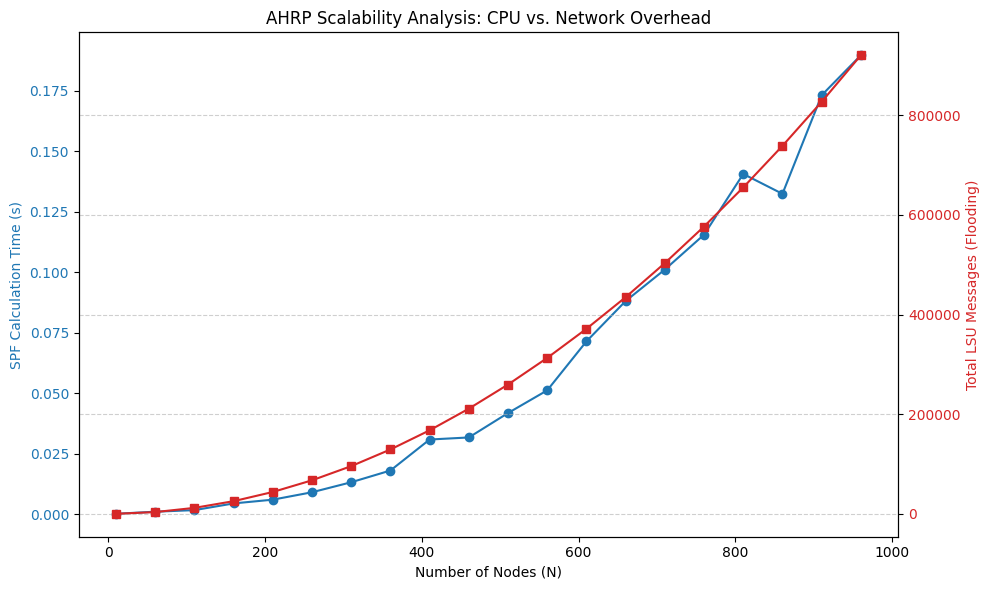

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import numpy as np

def benchmark_scalability(max_nodes):
    node_counts = range(10, max_nodes + 1, 50)
    spf_times = []
    message_counts = []
    
    for n in node_counts:
        # Create a complete graph (worst case for mesh density)
        # In a complete graph, E = n*(n-1)/2
        G = nx.complete_graph(n)
        for (u, v) in G.edges():
            G.edges[u,v]['weight'] = 1.0
            
        # 1. Benchmark Computational Load (SPF Calculation)
        start_time = time.perf_counter()
        nx.single_source_dijkstra_path(G, 0, weight='weight')
        end_time = time.perf_counter()
        spf_times.append(end_time - start_time)
        
        # 2. Benchmark Communication Overhead (LSU Flooding)
        # In a standard flood, each node sends an LSU to all neighbors
        # Total messages = 2 * E (each edge used twice)
        message_counts.append(2 * G.number_of_edges())

    # --- PLOTTING ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Computational Load
    color = 'tab:blue'
    ax1.set_xlabel('Number of Nodes (N)')
    ax1.set_ylabel('SPF Calculation Time (s)', color=color)
    ax1.plot(node_counts, spf_times, marker='o', color=color, label='CPU Load (Dijkstra)')
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot Communication Overhead
    ax2 = ax1.twinx() 
    color = 'tab:red'
    ax2.set_ylabel('Total LSU Messages (Flooding)', color=color)
    ax2.plot(node_counts, message_counts, marker='s', color=color, label='Network Overhead')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('AHRP Scalability Analysis: CPU vs. Network Overhead')
    fig.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

if __name__ == "__main__":
    # Test scalability from 5 to 100 nodes
    benchmark_scalability(1000)